# 05 - Test final avec calibration

Ce notebook évalue le modèle **SmallCNN** sur le dossier **Testing** en utilisant :

- le meilleur checkpoint `best_smallcnn_baseline.pt`
- l'inférence avec **TTA**
- la **calibration Platt** apprise sur la validation
- un seuil final de **0.5** sur les probabilités calibrées

## Objectifs
- charger le checkpoint final du modèle ;
- charger le calibrateur sauvegardé depuis le notebook 04 ;
- calculer les probabilités TTA sur le jeu de test ;
- appliquer la calibration ;
- produire les prédictions finales ;
- afficher la matrice de confusion et les métriques finales.


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('SRC_DIR =', SRC_DIR)


PROJECT_ROOT = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification
SRC_DIR = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/src


In [3]:
import json
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

from brain_tumor_mri.data.dataset import BrainMRIDataset
from brain_tumor_mri.data.transforms import get_tta_transforms
from brain_tumor_mri.models.builder import build_model
from brain_tumor_mri.inference.tta import predict_probabilities_tta
from brain_tumor_mri.evaluation.metrics import compute_auprc
from brain_tumor_mri.utils import get_device, set_seed


## Configuration


In [4]:
CONFIG = {
    'seed': 42,
    'model_name': 'cnn_small',
    'num_classes': 2,
    'pretrained': False,
    'img_size': 224,
    'threshold': 0.5,
    'checkpoint_name': 'best_smallcnn_baseline.pt',
    'calibrator_name': 'calibrator.pkl',
}

CONFIG


{'seed': 42,
 'model_name': 'cnn_small',
 'num_classes': 2,
 'pretrained': False,
 'img_size': 224,
 'threshold': 0.5,
 'checkpoint_name': 'best_smallcnn_baseline.pt',
 'calibrator_name': 'calibrator.pkl'}

## Chemins et device


In [5]:
set_seed(CONFIG['seed'])
device = get_device()

TEST_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'brain_mri' / 'Testing'
CHECKPOINT_PATH = PROJECT_ROOT / 'artifacts' / 'checkpoints' / CONFIG['checkpoint_name']
CALIBRATOR_PATH = PROJECT_ROOT / 'artifacts' / CONFIG['calibrator_name']

print('Device:', device)
print('TEST_ROOT =', TEST_ROOT)
print('CHECKPOINT_PATH =', CHECKPOINT_PATH)
print('CALIBRATOR_PATH =', CALIBRATOR_PATH)
print('Checkpoint exists:', CHECKPOINT_PATH.exists())
print('Calibrator exists:', CALIBRATOR_PATH.exists())


Device: cpu
TEST_ROOT = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/data/raw/brain_mri/Testing
CHECKPOINT_PATH = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_smallcnn_baseline.pt
CALIBRATOR_PATH = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/calibrator.pkl
Checkpoint exists: True
Calibrator exists: True


## Charger le modèle final


In [6]:
model = build_model(
    model_name=CONFIG['model_name'],
    num_classes=CONFIG['num_classes'],
    pretrained=CONFIG['pretrained'],
    img_size=CONFIG['img_size'],
).to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
else:
    model.load_state_dict(ckpt)

model.eval()
print('Checkpoint loaded successfully.')


Checkpoint loaded successfully.


## Charger le calibrateur


In [7]:
calibrator = joblib.load(CALIBRATOR_PATH)
print('Calibrator loaded successfully.')
print(calibrator)


Calibrator loaded successfully.
LogisticRegression()


## Charger le jeu de test

Le dossier `Testing` est utilisé ici pour la première fois comme vraie évaluation finale.


In [8]:
test_dataset = BrainMRIDataset(TEST_ROOT, transform=None)

print('Test size:', len(test_dataset))
print('Test distribution:', Counter(test_dataset.get_labels()))


Test size: 394
Test distribution: Counter({1: 289, 0: 105})


## Inference avec TTA


In [9]:
tta_transforms = get_tta_transforms(img_size=CONFIG['img_size'])

y_true, y_probs_raw = predict_probabilities_tta(
    model=model,
    dataset=test_dataset,
    device=device,
    tta_transforms=tta_transforms,
)

y_true = np.array(y_true)
y_probs_raw = np.array(y_probs_raw)

print('Raw test PRAUC:', compute_auprc(y_true, y_probs_raw))
print('Raw probabilities range:', float(y_probs_raw.min()), '->', float(y_probs_raw.max()))


Raw test PRAUC: 0.9516542707285169
Raw probabilities range: 2.1098823665965938e-07 -> 1.0


## Appliquer la calibration Platt


In [10]:
y_probs_cal = calibrator.predict_proba(y_probs_raw.reshape(-1, 1))[:, 1]

print('Calibrated test PRAUC:', compute_auprc(y_true, y_probs_cal))
print('Calibrated probabilities range:', float(y_probs_cal.min()), '->', float(y_probs_cal.max()))


Calibrated test PRAUC: 0.9516542707285169
Calibrated probabilities range: 0.13238504068854007 -> 0.9764893550027693


## Prédictions finales avec seuil 0.5

Après calibration, on revient à un seuil standard `0.5`.


In [11]:
THRESHOLD = CONFIG['threshold']
y_pred = (y_probs_cal >= THRESHOLD).astype(int)

print('Threshold used:', THRESHOLD)


Threshold used: 0.5


## Matrice de confusion


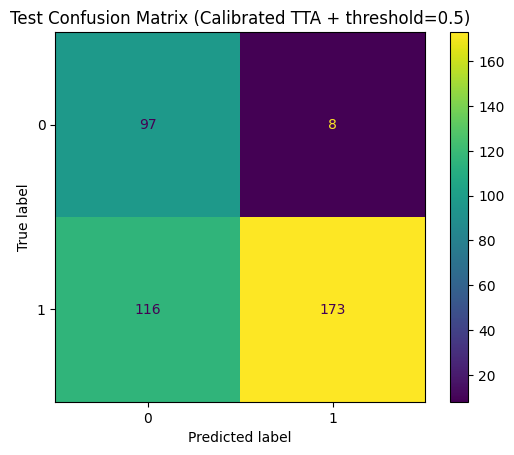

TN = 97
FP = 8
FN = 116
TP = 173


In [12]:
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f'Test Confusion Matrix (Calibrated TTA + threshold={THRESHOLD})')
plt.show()

print(f'TN = {tn}')
print(f'FP = {fp}')
print(f'FN = {fn}')
print(f'TP = {tp}')


## Rapport de classification


In [13]:
print(classification_report(y_true, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.4554    0.9238    0.6101       105
           1     0.9558    0.5986    0.7362       289

    accuracy                         0.6853       394
   macro avg     0.7056    0.7612    0.6731       394
weighted avg     0.8224    0.6853    0.7026       394



## Résumé final chiffré


In [14]:
results = {
    'setup': f'Calibrated TTA + threshold {THRESHOLD}',
    'test_size': int(len(test_dataset)),
    'accuracy': float(accuracy_score(y_true, y_pred)),
    'precision': float(precision_score(y_true, y_pred, zero_division=0)),
    'recall': float(recall_score(y_true, y_pred, zero_division=0)),
    'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    'prauc_raw': float(compute_auprc(y_true, y_probs_raw)),
    'prauc_calibrated': float(compute_auprc(y_true, y_probs_cal)),
    'TN': int(tn),
    'FP': int(fp),
    'FN': int(fn),
    'TP': int(tp),
}

pd.DataFrame([results])


,setup,test_size,accuracy,precision,recall,f1,prauc_raw,prauc_calibrated,TN,FP,FN,TP
0,Calibrated TTA + threshold 0.5,394,0.685279,0.955801,0.598616,0.73617,0.951654,0.951654,97,8,116,173


## Résumé JSON prêt pour le rapport


In [21]:
summary = {
    'checkpoint_path': str(CHECKPOINT_PATH),
    'calibrator_path': str(CALIBRATOR_PATH),
    'test_root': str(TEST_ROOT),
    'threshold_used': THRESHOLD,
    'results': results,
}

print(json.dumps(summary, indent=2))


{
  "checkpoint_path": "/home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_smallcnn_baseline.pt",
  "calibrator_path": "/home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/calibrator.pkl",
  "test_root": "/home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/data/raw/brain_mri/Testing",
  "threshold_used": 0.5,
  "results": {
    "setup": "Calibrated TTA + threshold 0.5",
    "test_size": 394,
    "accuracy": 0.6852791878172588,
    "precision": 0.9558011049723757,
    "recall": 0.5986159169550173,
    "f1": 0.7361702127659574,
    "prauc_raw": 0.9516542707285169,
    "prauc_calibrated": 0.9516542707285169,
    "TN": 97,
    "FP": 8,
    "FN": 116,
    "TP": 173
  }
}


In [22]:
# testons les seuil de probab
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_probs_cal >= t).astype(int)
    
    from sklearn.metrics import recall_score
    recall = recall_score(y_true, y_pred)
    
    print(f"Threshold {t} → Recall: {recall:.4f}")

Threshold 0.1 → Recall: 1.0000
Threshold 0.2 → Recall: 0.8166
Threshold 0.3 → Recall: 0.7439
Threshold 0.4 → Recall: 0.6540
Threshold 0.5 → Recall: 0.5986


## Conclusion

La calibration des probabilités (Platt scaling) a été explorée afin de rendre l'utilisation d’un seuil standard (0.5) plus pertinente.

Cependant, les résultats sur le jeu de test montrent que le seuil 0.5 reste sous-optimal, indiquant que le modèle produit des probabilités globalement faibles.

Une analyse des seuils a donc été réalisée, révélant qu’un seuil plus faible (≈ 0.2–0.3) permet d’améliorer significativement le recall.

Ainsi, le choix final repose sur un ajustement du seuil plutôt que sur la calibration seule.(voir code au 
